## Splitting full articles into snippets

### What we are doing
We have 2,700 full newspaper articles that we want to classify using the three focus categories identified above (Actor categories, Character Role, Conflict types). To do this, we need to break each article into snippets that can be passed to the classifier one at a time.

We use a **sentence-grouped sliding window** approach:
- Sentences are grouped together until a target word count is reached (60–80 words)
- The window then advances by one sentence at a time (one-sentence overlap between consecutive windows)
- Snippets shorter than 20 words are discarded as uninformative fragments

### Why this approach
Our labeled training data consists of snippets manually selected by human coders. The structural analysis above shows that the vast majority of these fall between 30 and 100 words, with a median of 53 words. The sentence-grouped sliding window is the closest mechanical approximation to this process: it preserves sentence boundaries (so no clause is cut mid-way), and the one-sentence overlap ensures that content spanning two consecutive windows is not missed.

Fixed-word windows were rejected because they cut sentences arbitrarily, degrading the linguistic cues (actor mentions, role attributions, conflict framings) that the classifier relies on. Paragraph-based splits were rejected because newspaper paragraphs vary too widely in length and often fall outside the 30–100 word range of the training data.

### What to expect
Most snippets produced by this mechanical split will not contain codeable content — they cover background information, transitions, or context unrelated to the conflict framing categories. This is normal. A relevance filter is applied to the sliding-window output to reduce noise: only snippets scoring ≥ 2 on a keyword-based relevance heuristic are retained and saved as `snippets_qual_filter.csv`, which is the input to `NB3A_Conflict_Codes_Training.ipynb`.


In [2]:
import pandas as pd
import re
import seaborn as sns
import matplotlib.pyplot as plt

LN_PATH = '../ln_preprocessing/ln_data_final.csv'

ln_full = pd.read_csv(LN_PATH)

# Remove URLs (including markdown reference-link blocks like "[ 6]: https://...")
ln_full['Text_body'] = (
    ln_full['Text_body']
    .str.replace(r'(?:\[\s*\d+\]:\s*)?https?://\S+', '', regex=True)
    .str.strip()
)

print(f"Total articles in ln_data_final   : {ln_full['ID'].nunique()}")

fname = '../ln_labeling/labeled_data_n154.xlsx'
training = pd.read_excel(fname)
training = training[['Text', 'Source', 'Codes', 'Number of Codes']]

# ── get training article IDs ─────────────────────────────────────────────────
# training 'Source' column has a .txt suffix: strip it to match
training_ids = set(
    training['Source'].dropna()
    .str.replace(r'\.txt$', '', regex=True)
    .unique()
)
print(f"Unique articles in training set   : {len(training_ids)}")

# ── exclude training articles ────────────────────────────────────────────────
ln_inference = ln_full[~ln_full['ID'].isin(training_ids)].reset_index(drop=True)

print(f"Articles excluded (in training)   : {len(ln_full) - len(ln_inference)}")
print(f"Distinct IDs remaining            : {ln_inference['ID'].nunique()}")
ln_inference.head(3)

# ── outlet-level quality filter ─────────────────────────────────────────────
# Outlet_Name format: 'Outlet Name, 1234words' — match on startswith
DROP_OUTLETS = {
    'CE Noticias Financieras English',
    'Metal Bulletin Daily Alerts',
    'American Metal Market (AMM)',
    'Commodity Online',
    'Proactive Investors (UK)',
    'MENAFN - Market Reports (English)',
}

mask_drop = ln_inference['Outlet_Name'].fillna('').apply(
    lambda x: any(x.startswith(o) for o in DROP_OUTLETS)
)
ln_inference = ln_inference[~mask_drop].reset_index(drop=True)
print(f"Articles dropped (low-quality outlets): {mask_drop.sum()}")
print(f"Articles remaining for inference       : {len(ln_inference)}")

Total articles in ln_data_final   : 2334
Unique articles in training set   : 151
Articles excluded (in training)   : 151
Distinct IDs remaining            : 2183
Articles dropped (low-quality outlets): 457
Articles remaining for inference       : 1726


In [3]:
import nltk
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
from nltk.tokenize import sent_tokenize

TARGET_MIN  = 60   # start a new window once we hit this
TARGET_MAX  = 80   # hard cap — if a single sentence exceeds this we keep it anyway
MIN_SNIPPET = 20   # discard fragments shorter than this
OVERLAP     = 1    # sentences carried over into the next window

def sliding_window_snippets(text, target_min=TARGET_MIN, target_max=TARGET_MAX,
                             min_words=MIN_SNIPPET, overlap=OVERLAP):
    sentences = sent_tokenize(str(text))
    snippets = []
    i = 0
    while i < len(sentences):
        window = []
        word_count = 0
        j = i
        while j < len(sentences):
            w = len(sentences[j].split())
            if word_count + w > target_max and window:
                break
            window.append(sentences[j])
            word_count += w
            j += 1
            if word_count >= target_min:
                break
        snippet = ' '.join(window).strip()
        if len(snippet.split()) >= min_words:
            snippets.append(snippet)
        # advance by (window size - overlap), minimum 1
        advance = max(1, len(window) - overlap)
        i += advance
    return snippets

# ── apply to all inference articles ─────────────────────────────────────────
rows = []
for _, article in ln_inference.iterrows():
    for snippet in sliding_window_snippets(article['Text_body']):
        rows.append({
            'article_id'  : article['ID'],
            'title'       : article['Title'],
            'outlet'      : article['Outlet_Name'],
            'date'        : article['Date'],
            'snippet'     : snippet,
            'word_count'  : len(snippet.split()),
        })

snippets_df = pd.DataFrame(rows)

# ── summary ──────────────────────────────────────────────────────────────────
print(f"Articles processed          : {ln_inference['ID'].nunique()}")
print(f"Total snippets generated    : {len(snippets_df)}")
print(f"Avg snippets per article    : {len(snippets_df) / ln_inference['ID'].nunique():.1f}")
print(f"\nSnippet word count:")
print(snippets_df['word_count'].describe().round(1))
print(f"\nSnippets < {MIN_SNIPPET} words (discarded): already excluded")
print(f"Snippets 20–60 words  : {((snippets_df['word_count'] >= 20) & (snippets_df['word_count'] < 60)).sum()}")
print(f"Snippets 60–80 words  : {((snippets_df['word_count'] >= 60) & (snippets_df['word_count'] <= 80)).sum()}")
print(f"Snippets > 80 words   : {(snippets_df['word_count'] > 80).sum()}")

snippets_df.head(3)

Articles processed          : 1726
Total snippets generated    : 73410
Avg snippets per article    : 42.5

Snippet word count:
count    73410.0
mean        65.6
std         31.2
min         20.0
25%         59.0
50%         65.0
75%         72.0
max       2087.0
Name: word_count, dtype: float64

Snippets < 20 words (discarded): already excluded
Snippets 20–60 words  : 18936
Snippets 60–80 words  : 52915
Snippets > 80 words   : 1559


,article_id,title,outlet,date,snippet,word_count
0,urn:contentItem:6313-C6K1-DY4H-K3FJ-00000-00,Mining holds the key to a green future - no wo...,"The Guardian (London), BUSINESS; Version:2, 11...",2021-06-27,Mining holds the key to a green future - no wo...,68
1,urn:contentItem:6313-C6K1-DY4H-K3FJ-00000-00,Mining holds the key to a green future - no wo...,"The Guardian (London), BUSINESS; Version:2, 11...",2021-06-27,"Not any more. Today, the shallow sandbank, loc...",62
2,urn:contentItem:6313-C6K1-DY4H-K3FJ-00000-00,Mining holds the key to a green future - no wo...,"The Guardian (London), BUSINESS; Version:2, 11...",2021-06-27,Welcome to the beginning of the end of the fos...,73


## Snippet split — sanity check

**What to expect:** A typical LexisNexis article in this dataset runs ~500–900 words. With 60–80 word windows and one-sentence overlap, each article should yield roughly 8–15 snippets, putting the total somewhere between 15,000 and 30,000 snippets.

**Distribution check:** The median snippet word count should sit in the 60–80 word range. A long tail above 80 words is normal — it reflects articles with long sentences that exceed the target cap but are kept intact. A secondary bump below 60 words is also expected for article-ending fragments (last sentence(s) of an article that don't fill a full window but pass the 20-word minimum).

**Red flags to watch for:**
- Median well below 50 words → windows are too short; consider raising `TARGET_MIN`
- Very high snippet count (>50 per article on average) → articles may contain boilerplate/repeated text that inflates the count
- Many snippets > 150 words → articles likely contain very long run-on sentences; consider splitting on punctuation as a fallback

In [4]:
print(f"Articles processed         : {ln_inference['ID'].nunique()}")
print(f"Total snippets             : {len(snippets_df)}")
print(f"Avg snippets per article   : {len(snippets_df) / ln_inference['ID'].nunique():.1f}")
print(f"\nWord count distribution:")
print(snippets_df['word_count'].describe().round(1))
print(f"\nSnippets 20–59 words  : {((snippets_df['word_count'] >= 20) & (snippets_df['word_count'] < 60)).sum()}")
print(f"Snippets 60–80 words  : {((snippets_df['word_count'] >= 60) & (snippets_df['word_count'] <= 80)).sum()}")
print(f"Snippets 81–150 words : {((snippets_df['word_count'] > 80) & (snippets_df['word_count'] <= 150)).sum()}")
print(f"Snippets > 150 words  : {(snippets_df['word_count'] > 150).sum()}")

Articles processed         : 1726
Total snippets             : 73410
Avg snippets per article   : 42.5

Word count distribution:
count    73410.0
mean        65.6
std         31.2
min         20.0
25%         59.0
50%         65.0
75%         72.0
max       2087.0
Name: word_count, dtype: float64

Snippets 20–59 words  : 18936
Snippets 60–80 words  : 52915
Snippets 81–150 words : 1028
Snippets > 150 words  : 531


## Snippet split — results

**6 low-quality outlets dropped** (CE Noticias Financieras, Metal Bulletin Daily Alerts, American Metal Market, Commodity Online, Proactive Investors UK, MENAFN Market Reports), removing 457 articles. This reduces the inference set from 2,181 to **1,724 articles**.

The word count distribution is healthy: median 65 words, and the majority of snippets land in the 60–80 word target band.

**Long tail:** a small number of snippets exceed 150 words. These are single sentences too long to split further — likely tables, bullet lists run together, or garbled OCR. Small in number but worth filtering before classification.

In [5]:
# top 5 articles by snippet count
top5_ids = (
    snippets_df.groupby('article_id')
    .size()
    .sort_values(ascending=False)
    .head(5)
    .reset_index()
    .rename(columns={0: 'snippet_count'})
)

# join with full article text for manual inspection
top5 = top5_ids.merge(ln_inference[['ID', 'Title', 'Outlet_Name', 'Date', 'Text_body']],
                      left_on='article_id', right_on='ID').drop(columns='ID')


In [6]:
scmp = snippets_df[snippets_df['outlet'].str.contains('South China Morning Post', case=False, na=False)].copy()
print(f'SCMP snippets     : {len(scmp)}')
print(f'Distinct articles : {scmp["article_id"].nunique()}')

OUT = r'C:\Users\charlott\Dropbox (Personal)\Paper_Indonesia_Nickel\ln_tests\snippets_scmp.xlsx'
scmp.to_excel(OUT, index=False)
print(f'Saved: {OUT}')

SCMP snippets     : 1559
Distinct articles : 62
Saved: C:\Users\charlott\Dropbox (Personal)\Paper_Indonesia_Nickel\ln_tests\snippets_scmp.xlsx


In [7]:
asia_times = snippets_df[snippets_df['outlet'].str.contains('Asia Times', case=False, na=False)].copy()
print(f'Asia Times snippets : {len(asia_times)}')
print(f'Distinct articles   : {asia_times["article_id"].nunique()}')

OUT = r'C:\Users\charlott\Dropbox (Personal)\Paper_Indonesia_Nickel\ln_tests\snippets_asia_times.xlsx'
asia_times.to_excel(OUT, index=False)
print(f'Saved: {OUT}')


Asia Times snippets : 867
Distinct articles   : 26
Saved: C:\Users\charlott\Dropbox (Personal)\Paper_Indonesia_Nickel\ln_tests\snippets_asia_times.xlsx


In [8]:
OUT = r'C:\Users\charlott\Dropbox (Personal)\Paper_Indonesia_Nickel\ln_training\snippets_df.xlsx'
snippets_df.to_excel(OUT, index=False)
print(f'Saved {len(snippets_df):,} snippets to: {OUT}')


Saved 73,410 snippets to: C:\Users\charlott\Dropbox (Personal)\Paper_Indonesia_Nickel\ln_training\snippets_df.xlsx


In [9]:
import re
import json as _json

def _compile(*terms):
    """Compile an OR-regex from terms matched as whole words (case-insensitive)."""
    alts = [r'\b' + re.escape(t.lower()) + r'\b' for t in terms]
    return re.compile('|'.join(alts), re.IGNORECASE)

def _hit(pat, text):
    return bool(pat.search(text))

# ── Load codebook entity terms ────────────────────────────────────────────────
def _expand_cb(terms):
    out = []
    for raw in terms:
        for seg in str(raw).split(';'):
            seg = seg.strip()
            if not seg:
                continue
            for alt in seg.split(' OR '):
                alt = alt.strip()
                if alt:
                    out.append(alt)
    return out

def _ent_terms(actor_labels):
    """Named entities only (no trigger phrases) for the given actor labels."""
    terms, seen = [], set()
    for rec in _codebook_rel:
        if rec['actor_label'] in actor_labels:
            for t in _expand_cb(rec['named_entities']):
                tl = t.lower().strip()
                if tl and tl not in seen:
                    seen.add(tl)
                    terms.append(tl)
    return terms

with open('ner_actor_codebook.json', 'r', encoding='utf-8') as _fh:
    _codebook_rel = _json.load(_fh)

_chinese_ent_terms = _ent_terms({
    'Chinese DFIs (banks)',
    'Chinese firms/SOEs',
    'Chinese government',
    'Chinese worker',
})

# Excludes 'Indonesian local community & workers' — contains generic terms
# (residents, fishermen, households) that would inflate scores.
_indo_ent_terms = _ent_terms({
    'Indonesian government: central government/president',
    'Indonesian government: local government (provincial/regional officials)',
    'Indonesian firms and local elites',
    'Indonesian local civil society',
})

print(f'Chinese named entities loaded   : {len(_chinese_ent_terms)}')
print(f'Indonesian named entities loaded: {len(_indo_ent_terms)}')

# ── Anchor groups (Rules A–G) ─────────────────────────────────────────────────
A_LOC = _compile(
    'indonesia', 'indonesian', 'jakarta', 'sulawesi', 'central sulawesi',
    'southeast sulawesi', 'north maluku', 'morowali', 'weda bay', 'halmahera',
    'obi island', 'konawe', 'bahodopi', 'pomalaa', 'raja ampat',
    'west kalimantan', 'north kalimantan',
    'jokowi', 'joko widodo', 'prabowo', 'prabowo subianto', 'luhut',
    'luhut binsar panjaitan', 'muhammad lutfi', 'esdm', 'bkpm', 'ina',
    'bahlil', 'anies', 'gibran',
)
A_NICKEL = _compile(
    'nickel', 'smelter', 'smelting', 'ferronickel', 'npi', 'hpal', 'mhp',
    'battery material', 'battery materials', 'ev battery', 'electric vehicle battery',
    'battery supply chain', 'stainless steel', 'downstreaming', 'export ban',
    'industrial park', 'captive coal', 'nickel export ban', 'ore export ban',
    'resource nationalism', 'tailings pipeline', 'conflict-free nickel',
    'processing plant', 'nickel processing', 'nickel mining', 'nickel ore',
    'battery-materials boom', 'stainless steel boom', 'deep-sea tailings',
    'hpal plant', 'mhp plant',
)
B_SINGLE = _compile(
    'imip', 'iwip', 'pt gni', 'pt vdni', 'pt oss', 'morowali industrial park',
    'weda bay industrial park', 'antam', 'harita nickel', 'vale indonesia',
    'ibc', 'itss', 'pt vdn', 'pt virtue dragon', 'fscrir',
)
B_COMPOUND = [
    (_compile('huayou'),                       _compile('morowali')),
    (_compile('tsingshan'),                    _compile('morowali')),
    (_compile('norilsk nickel'),               _compile('indonesia')),
    (_compile('metallurgical corp of china'),  _compile('indonesia')),
]
def rule_b(t):
    if _hit(B_SINGLE, t): return True
    return any(_hit(a, t) and _hit(b, t) for a, b in B_COMPOUND)

C_CHINESE = _compile(
    'chinese dfi', 'chinese bank', 'chinese firm', 'chinese firms', 'chinese soe',
    'chinese government', 'chinese worker', 'chinese workers', 'chinese-backed',
    'chinese-owned', 'chinese-funded', 'chinese investor', 'chinese company',
    'chinese ambassador', 'chinese national', 'chinese nationals', 'chinese state councillor',
    'wang yi', 'chinese subcontractor', 'rptka', 'chinese batch arrival',
    'mainland worker', 'mainland workers', 'chinese labour', 'chinese labor',
    'chinese employees', 'chinese personnel', 'chinese migrant',
)
D_LOCAL = _compile(
    'resident', 'residents', 'villager', 'villagers', 'fishermen', 'fisherman',
    'indigenous', 'adat', 'local worker', 'local workers', 'local community',
    'walhi', 'jatam', 'celios', 'icel', 'greenpeace indonesia', 'trend asia',
    'aman', 'aeer', 'pwyp indonesia', 'union', 'unions', 'labour union',
    'labor union', 'trade union',
)
D_CONTEXT = _compile(
    'nickel', 'smelter', 'smelting', 'mining', 'morowali', 'weda bay',
    'sulawesi', 'halmahera', 'industrial park', 'imip', 'pt gni', 'pt vdni',
    'pt oss', 'antam', 'harita nickel', 'pollution', 'accident', 'explosion',
    'protest', 'strike', 'land dispute', 'labour dispute', 'labor dispute',
    'workplace safety', 'tailings', 'deforestation', 'health risk',
    'anti-chinese', 'deport workers', 'stealing jobs', 'resentment',
    'chinese workers', 'deportation',
)
E_INTL = _compile(
    'eu trade commissioner', 'valdis dombrovskis', 'wto panel', 'gatt',
    'us trade representative', 'ustr', 'wto appellate body',
    'international partners group', 'jetp', 'world bank', 'iea', 'g7',
    'glencore', 'rio tinto', 'bhp', 'volkswagen', 'hyundai', 'ford',
    'lg energy', 'samsung sdi', 'panasonic', 'posco', 'tesla',
    'global witness', 'amnesty international', 'survival international',
    'human rights watch', 'global voices',
    'european union', 'oecd', 'us department of labor', 'us state department',
    'asian development bank',
)

# G_CHINESE_ENT: specific Chinese entity names (codebook named entities only, 2 pts).
# Catches Tsingshan, CATL, Bank of China, Xi Jinping, etc. without requiring "china/chinese".
G_CHINESE_ENT = re.compile(
    '|'.join(r'\b' + re.escape(t) + r'\b' for t in _chinese_ent_terms),
    re.IGNORECASE,
)

# G_INDO_ENT: specific Indonesian entity names (codebook named entities only, 2 pts).
# Excludes 'Indonesian local community & workers' — keeps out fishermen, residents, etc.
# Covers: Jokowi, Prabowo, Jakarta, WALHI, JATAM, CELIOS, IMIP, Harita, provincial gov, etc.
G_INDO_ENT = re.compile(
    '|'.join(r'\b' + re.escape(t) + r'\b' for t in _indo_ent_terms),
    re.IGNORECASE,
)

# F_CHINA expanded: country name + codebook entity names (for bilateral co-occurrence test)
F_CHINA = re.compile(
    r'\b(?:china|chinese)\b|' +
    '|'.join(r'\b' + re.escape(t) + r'\b' for t in _chinese_ent_terms),
    re.IGNORECASE,
)
F_INDO  = _compile('indonesia', 'indonesian')
F_DIPLO = _compile(
    'indonesia-china', 'indonesia–china', 'bilateral cooperation',
    'bilateral investment',
    'indonesian defence minister', 'indonesian defense minister',
)
F_LINK = _compile(
    'nickel', 'mining', 'investment', 'mineral', 'battery', 'energy',
    'resources', 'industrial park', 'smelter', 'downstreaming',
    'supply chain', 'critical mineral', 'battery material', 'infrastructure',
)

# ── Relevance score ───────────────────────────────────────────────────────────
# Weight:  4 = strong case-specific anchor (Rule B)
#          2 = specific domain / actor signal
#          1 = supporting / contextual signal
# Threshold >= 2 calibrated on 390 labeled snippets:
#   recall 83% overall, 74–93% per category.

def relevance_score(text):
    t = str(text).lower()
    s = 0
    if rule_b(t):               s += 4   # strong case-specific anchor
    s += 2 * _hit(A_NICKEL, t)            # nickel/industrial domain
    s += 2 * _hit(C_CHINESE, t)           # Chinese actor phrase
    s += 2 * _hit(G_CHINESE_ENT, t)       # specific Chinese entity name (codebook)
    s += 2 * _hit(G_INDO_ENT, t)          # specific Indonesian entity name (codebook)
    s += 2 * _hit(D_LOCAL, t)             # local civil society
    s += 2 * _hit(E_INTL, t)              # international actor
    s += 2 * _hit(F_DIPLO, t)             # bilateral/diplomatic signal
    s += 1 * _hit(A_LOC, t)               # Indonesia/location (supporting)
    s += 1 * _hit(D_CONTEXT, t)           # conflict/project context
    s += 1 * int(_hit(F_CHINA, t) and _hit(F_INDO, t))  # China + Indonesia pair
    s += 1 * _hit(F_LINK, t)              # economic/resource link
    return s

THRESHOLD = 2

snippets_df['relevance_score'] = snippets_df['snippet'].apply(relevance_score)
snippets_df['pass_filter']     = snippets_df['relevance_score'] >= THRESHOLD

# ── Summary ───────────────────────────────────────────────────────────────────
n_total = len(snippets_df)
n_pass  = snippets_df['pass_filter'].sum()
print(f'Total snippets          : {n_total:,}')
print(f'Pass (score >= {THRESHOLD})       : {n_pass:,}  ({100 * n_pass / n_total:.1f}%)')
print(f'Filtered out            : {n_total - n_pass:,}  ({100 * (1 - n_pass / n_total):.1f}%)')
print()
print('Score distribution (full set):')
print(snippets_df['relevance_score'].value_counts().sort_index().to_string())

# ── Save ──────────────────────────────────────────────────────────────────────
qual = (snippets_df[snippets_df['pass_filter']]
        .drop(columns=['pass_filter'])
        .reset_index(drop=True))

OUT_QUAL = '../ln_training/snippets_qual_filter.csv'
qual.to_csv(OUT_QUAL, index=False)
print(f'\nSaved {len(qual):,} filtered snippets → {OUT_QUAL}')
qual.head(3)


Chinese named entities loaded   : 49
Indonesian named entities loaded: 75
Total snippets          : 73,410
Pass (score >= 2)       : 29,221  (39.8%)
Filtered out            : 44,189  (60.2%)

Score distribution (full set):
relevance_score
0     32147
1     12042
2      8509
3      4527
4      7465
5      3509
6      2449
7       886
8       780
9       270
10      322
11      141
12      175
13       44
14      110
15        6
16       26
17        1
18        1

Saved 29,221 filtered snippets → ../ln_training/snippets_qual_filter.csv


,article_id,title,outlet,date,snippet,word_count,relevance_score
0,urn:contentItem:6313-C6K1-DY4H-K3FJ-00000-00,Mining holds the key to a green future - no wo...,"The Guardian (London), BUSINESS; Version:2, 11...",2021-06-27,Mining holds the key to a green future - no wo...,68,2
1,urn:contentItem:6313-C6K1-DY4H-K3FJ-00000-00,Mining holds the key to a green future - no wo...,"The Guardian (London), BUSINESS; Version:2, 11...",2021-06-27,That will take a fivefold increase in global r...,65,2
2,urn:contentItem:6313-C6K1-DY4H-K3FJ-00000-00,Mining holds the key to a green future - no wo...,"The Guardian (London), BUSINESS; Version:2, 11...",2021-06-27,Expanding renewable energy is a mineral intens...,55,4


## Conflict-centered snippet extraction

Instead of sliding-window snippets over every article, we locate sentences that mention a conflict keyword and build a **100–120 word window** around each such sentence.
Overlapping windows are merged. This replaces the uniform sliding-window approach for conflict classification —
only text near a conflict mention is passed to the NLI model.

The 100–120 word target is calibrated for the NLI input format: snippet + conflict-type definition together fit comfortably within `max_length=192` tokens without truncation, while providing ~2–3 sentences of context on each side of the keyword mention.

Keywords are matched case-insensitively; `s?` on each term covers regular English plurals.
`monopolies` is listed explicitly because `monopoly → monopolies` is irregular.


In [10]:
import re
import nltk
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
from nltk.tokenize import sent_tokenize
from nltk.stem import SnowballStemmer

_stemmer = SnowballStemmer('english')

# Single flat list of conflict-related terms for matching.
# This is intentionally broad so the extractor captures multiple shades
# of conflict language, including labor, land, environmental, governance,
# violence, and economic disputes.
CONFLICT_KEYWORDS = [
    'conflict', 'clash', 'tension', 'dispute', 'controversy', 'friction',
    'human rights', 'forced labor', 'forced labour', 'child labor', 'child labour',
    'exploitation', 'abuse', 'slavery', 'harassment', 'union busting',
    'collective bargaining', 'strike', 'riot', 'lockout', 'layoff', 'retrenchment',
    'land rights', 'eviction', 'evict', 'displacement', 'resettlement', 'compensation',
    'indigenous', 'community opposition', 'local resistance', 'community protest',
    'pollution', 'contamination', 'toxic waste', 'emission', 'emissions', 'tailings',
    'deforestation', 'health risk', 'water scarcity', 'poisoning', 'acid leak',
    'corruption', 'bribery', 'scandal', 'misconduct', 'fraud', 'lawsuit', 'litigation',
    'repression', 'intimidation', 'arrest', 'censorship', 'sanction', 'sanctions',
    'accident', 'explosion', 'explode', 'fire', 'fatality', 'injury', 'injure',
    'violence', 'assault', 'shooting',
    'monopoly', 'monopolies', 'dumping', 'boycott', 'trade dispute', 'supply chain risk',
    'backlash', 'protest', 'spill', 'collapse', 'unsustainable', 'price war',
    'environmental damage', 'social unrest', 'public outcry',
    'go demonstrate', 'demonstrate against',   # replaces bare 'demonstration' (false-positive: "demonstrate fiscal responsibility")
    'migrant labor', 'labor dispute', 'labour dispute', 'workers rights',
    'illegal mining', 'illegal logging', 'resource nationalism', 'environmental justice',
    'land grab', 'land seizure', 'humanitarian crisis', 'security risk', 'crime'
]


def _stem_tokens(phrase):
    """Stem each word in a phrase; return as a tuple for token-level matching."""
    return tuple(_stemmer.stem(w) for w in phrase.lower().split())

# Pre-compute stemmed keyword tuples once
_stemmed_kws = [_stem_tokens(kw) for kw in CONFLICT_KEYWORDS]


def _has_conflict(sentence):
    """True if any stemmed keyword sequence appears as a token run.
    Uses re.findall(r'\w+') so trailing punctuation (periods, commas)
    is stripped before stemming — avoids false negatives at sentence ends."""
    tokens = [_stemmer.stem(w) for w in re.findall(r'\w+', sentence.lower())]
    for sk in _stemmed_kws:
        n = len(sk)
        for i in range(len(tokens) - n + 1):
            if tokens[i:i + n] == list(sk):
                return True
    return False

print(f'Conflict keywords : {len(CONFLICT_KEYWORDS)}  '
      f'(stemmed to {len(set(_stemmed_kws))} unique stem sequences)')
print('Sample stems:', {kw: _stem_tokens(kw) for kw in
      ['protest', 'protesting', 'explosion', 'explode', 'eviction', 'riot', 'strike']})

# quick sanity check: punctuation-attached words must match
_test_cases = [('protests,', 'protest'), ('pollution.', 'pollution'), ('fires;', 'fire')]
for word, kw in _test_cases:
    tok_stem = _stemmer.stem(re.findall(r'\w+', word.lower())[0])
    kw_stem  = _stemmer.stem(kw)
    status   = 'OK' if tok_stem == kw_stem else 'FAIL'
    print(f'  {status}  "{word}" -> stem "{tok_stem}"  ==  "{kw}" stem "{kw_stem}"')

# verify the false-positive fix
_false_pos = 'to demonstrate fiscal responsibility'
_true_pos_1 = 'workers went to demonstrate against the company'
_true_pos_2 = 'workers demonstrated against the smelter'
_true_pos_3 = 'people go demonstrate in the streets'
print(f'\nFalse-positive sentence fires: {_has_conflict(_false_pos)}  (expected False)')
print(f'True-positive "demonstrate against" fires: {_has_conflict(_true_pos_1)}  (expected True)')
print(f'True-positive "demonstrated against" fires: {_has_conflict(_true_pos_2)}  (expected True)')
print(f'True-positive "go demonstrate" fires: {_has_conflict(_true_pos_3)}  (expected True)')

# ── Snippet extraction ────────────────────────────────────────────────────────
TARGET_MIN  = 100
TARGET_MAX  = 120
MIN_SNIPPET =  20
HARD_MAX    = 120


def conflict_centered_snippets(text,
                                target_min=TARGET_MIN, target_max=TARGET_MAX,
                                min_words=MIN_SNIPPET, hard_max=HARD_MAX):
    sentences = sent_tokenize(str(text))
    wc = [len(s.split()) for s in sentences]
    n  = len(sentences)

    anchors = [i for i, s in enumerate(sentences) if _has_conflict(s)]
    if not anchors:
        return []

    windows = []
    for a in anchors:
        lo, hi = a, a + 1
        total = wc[a]
        while total < target_min:
            added = False
            if hi < n and total + wc[hi] <= target_max:
                total += wc[hi]; hi += 1; added = True
            if lo > 0 and total + wc[lo - 1] <= target_max:
                total += wc[lo - 1]; lo -= 1; added = True
            if not added:
                break
        windows.append((lo, hi))

    windows.sort()
    merged = [list(windows[0])]
    for lo, hi in windows[1:]:
        if lo <= merged[-1][1]:
            merged[-1][1] = max(merged[-1][1], hi)
        else:
            merged.append([lo, hi])

    result = []
    for lo, hi in merged:
        chunk = ' '.join(sentences[lo:hi])
        words = chunk.split()
        if len(words) > hard_max:
            chunk = ' '.join(words[:hard_max])
        if len(chunk.split()) >= min_words:
            result.append(chunk)
    return result


# ── Apply to all inference articles ──────────────────────────────────────────
rows = []
for _, article in ln_inference.iterrows():
    for snippet in conflict_centered_snippets(article['Text_body']):
        rows.append({
            'article_id' : article['ID'],
            'title'      : article['Title'],
            'outlet'     : article['Outlet_Name'],
            'date'       : article['Date'],
            'snippet'    : snippet,
            'word_count' : len(snippet.split()),
        })

conflict_snippets_df = pd.DataFrame(rows)

print(f'\nArticles processed              : {ln_inference["ID"].nunique():,}')
print(f'Articles with >=1 conflict match: {conflict_snippets_df["article_id"].nunique():,}')
print(f'Total conflict-centered snippets: {len(conflict_snippets_df):,}')
print(f'Avg snippets per matched article: {len(conflict_snippets_df) / conflict_snippets_df["article_id"].nunique():.1f}')
print(f'\nWord count distribution:')
print(conflict_snippets_df['word_count'].describe().round(1))

Conflict keywords : 96  (stemmed to 92 unique stem sequences)
Sample stems: {'protest': ('protest',), 'protesting': ('protest',), 'explosion': ('explos',), 'explode': ('explod',), 'eviction': ('evict',), 'riot': ('riot',), 'strike': ('strike',)}
  OK  "protests," -> stem "protest"  ==  "protest" stem "protest"
  OK  "pollution." -> stem "pollut"  ==  "pollution" stem "pollut"
  OK  "fires;" -> stem "fire"  ==  "fire" stem "fire"

False-positive sentence fires: False  (expected False)
True-positive "demonstrate against" fires: True  (expected True)
True-positive "demonstrated against" fires: True  (expected True)
True-positive "go demonstrate" fires: True  (expected True)

Articles processed              : 1,726
Articles with >=1 conflict match: 1,710
Total conflict-centered snippets: 4,765
Avg snippets per matched article: 2.8

Word count distribution:
count    4765.0
mean      112.4
std         8.7
min        32.0
25%       106.0
50%       115.0
75%       120.0
max       120.0
Name: w

In [11]:
# ── Diagnostic: what geographic terms appear in non-Indonesia snippets? ───────
# This uses the snippet text directly rather than assuming a pre-existing column.

INDO_PAT = re.compile(r'\bindonesia\b|\bindonesian\b', re.IGNORECASE)
non_indo_mask = ~conflict_snippets_df['snippet'].apply(lambda t: bool(INDO_PAT.search(str(t))))
no_indo = conflict_snippets_df[non_indo_mask].copy()

print(f'Snippets without "Indonesia": {len(no_indo):,}  '
      f'({100 * len(no_indo) / len(conflict_snippets_df):.1f}% of total)')

# Broad list of country/region candidates to check presence of
CANDIDATE_GEOS = [
    'china', 'chinese',
    'drc', 'congo',
    'chile', 'chilean',
    'vietnam', 'viet nam',
    'philippines', 'philippine',
    'new caledonia',
    'australia', 'australian',
    'canada', 'canadian',
    'madagascar',
    'brazil', 'brazilian',
    'russia', 'russian',
    'cuba',
    'guatemala',
    'zambia',
    'zimbabwe',
    'myanmar', 'burma',
    'papua new guinea',
    'malaysia', 'malaysian',
    'india', 'indian',
    'south africa',
    'peru', 'peruvian',
    'colombia',
    'bolivia',
    'argentina',
    'ghana',
    'tanzania',
    'mozambique',
    'niger', 'nigeria',
    'europe', 'european',
    'america', 'american',
    'africa', 'african',
    'asia', 'asian',
]

hits = {}
for geo in CANDIDATE_GEOS:
    pat = re.compile(r'\b' + re.escape(geo) + r'\b', re.IGNORECASE)
    count = no_indo['snippet'].apply(lambda t: bool(pat.search(str(t)))).sum()
    if count > 0:
        hits[geo] = count

hits_s = pd.Series(hits).sort_values(ascending=False)
print(f'\nGeo terms present in non-Indonesia snippets (n={len(no_indo):,}):')
print(hits_s.to_string())

Snippets without "Indonesia": 3,087  (64.8% of total)

Geo terms present in non-Indonesia snippets (n=3,087):
china               720
chinese             307
asia                154
europe              138
africa              115
america             109
european            105
india               104
russia               69
american             68
brazil               65
asian                60
african              49
south africa         46
russian              41
chile                40
congo                40
drc                  40
australia            38
myanmar              38
vietnam              37
australian           35
new caledonia        33
malaysia             27
canada               26
indian               25
peru                 24
nigeria              22
zimbabwe             21
brazilian            21
zambia               19
argentina            14
canadian             14
papua new guinea     13
ghana                11
bolivia               9
chilean               9
mo

In [12]:
import json

# ── Load actor codebook (shared with NB3B) ────────────────────────────────────
def _expand_codebook_terms(terms):
    expanded = []
    for raw in terms:
        for segment in str(raw).split(';'):
            segment = segment.strip()
            if not segment:
                continue
            for alt in segment.split(' OR '):
                alt = alt.strip()
                if alt:
                    expanded.append(alt)
    return expanded

with open('ner_actor_codebook.json', 'r', encoding='utf-8') as fh:
    _codebook = json.load(fh)

def _codebook_pattern(actor_labels):
    """OR-regex from named entities + trigger phrases for the given actor labels."""
    terms, seen = [], set()
    for rec in _codebook:
        if rec['actor_label'] in actor_labels:
            all_terms = (
                _expand_codebook_terms(rec['named_entities']) +
                _expand_codebook_terms(rec['trigger_phrases'])
            )
            for t in all_terms:
                tl = t.lower().strip()
                if tl and tl not in seen:
                    seen.add(tl)
                    terms.append(r'\b' + re.escape(tl) + r'\b')
    return re.compile('|'.join(terms), re.IGNORECASE) if terms else re.compile(r'(?!)')

_CHINA_CONTENT = _codebook_pattern({
    'Chinese DFIs (banks)',
    'Chinese firms/SOEs',
    'Chinese government',
    'Chinese worker',
})

_INDO_ACTORS = _codebook_pattern({
    'Indonesian government: central government/president',
    'Indonesian government: local government (provincial/regional officials)',
    'Indonesian firms and local elites',
    'Indonesian local civil society',
    'Indonesian local community & workers',
})

# Geographic/institutional anchors not covered by the actor codebook
_INDO_GEO = re.compile(
    r'\b(?:morowali|sulawesi|halmahera|weda\s+bay|north\s+maluku|konawe|'
    r'bahodopi|pomalaa|obi\s+island|west\s+kalimantan|north\s+kalimantan|'
    r'raja\s+ampat|esdm|bkpm|pertamina|bukit\s+asam|imip|iwip)\b',
    re.IGNORECASE,
)

def _has_indo_content(t):
    return bool(_INDO_ACTORS.search(t)) or bool(_INDO_GEO.search(t))

def _has_china_content(t):
    return bool(_CHINA_CONTENT.search(t))

# print term counts loaded
for label_set, name in [
    ({'Chinese DFIs (banks)', 'Chinese firms/SOEs', 'Chinese government', 'Chinese worker'}, 'China'),
    ({'Indonesian government: central government/president',
      'Indonesian government: local government (provincial/regional officials)',
      'Indonesian firms and local elites', 'Indonesian local civil society',
      'Indonesian local community & workers'}, 'Indonesia'),
]:
    n_ent = sum(len(_expand_codebook_terms(r['named_entities']))
                for r in _codebook if r['actor_label'] in label_set)
    n_trg = sum(len(_expand_codebook_terms(r['trigger_phrases']))
                for r in _codebook if r['actor_label'] in label_set)
    print(f'{name}: {n_ent} entity terms + {n_trg} trigger phrases loaded from codebook')

# ── Post-extraction quality filters ──────────────────────────────────────────

_WTO    = re.compile(r'\bwto\b', re.IGNORECASE)
_NICKEL = re.compile(r'\bnickel\b', re.IGNORECASE)
_INDO   = re.compile(r'\bindonesia\b|\bindonesian\b', re.IGNORECASE)
_TONNE  = re.compile(r'\ba\s+tonne\b', re.IGNORECASE)

OTHER_COUNTRIES = [
    'drc', 'democratic republic of congo', 'dr congo', 'congo',
    'chile', 'chilean',
    'vietnam', 'viet nam', 'vietnamese',
    'philippines', 'philippine', 'filipino',
    'new caledonia',
    'australia', 'australian',
    'canada', 'canadian',
    'madagascar',
    'brazil', 'brazilian',
    'russia', 'russian',
    'cuba', 'cuban',
    'guatemala',
    'zambia', 'zambian',
    'zimbabwe',
    'myanmar', 'burma',
    'papua new guinea', 'png',
    'india', 'indian',
    'south africa', 'south african',
]
_OTHER = re.compile(
    r'\b(?:' + '|'.join(re.escape(c) for c in OTHER_COUNTRIES) + r')\b',
    re.IGNORECASE,
)

_NICKEL_ADJ = re.compile(
    r'\b(?:nickel|mining|mineral|minerals|battery|batteries|downstreaming|smelter|smelting)\b',
    re.IGNORECASE,
)

n_before = len(conflict_snippets_df)

def _keep(text):
    t = str(text)
    has_indo         = bool(_INDO.search(t))
    has_indo_content = _has_indo_content(t)
    # Rule 1: WTO mention → must also have nickel or Indonesia
    if _WTO.search(t) and not _NICKEL.search(t) and not has_indo:
        return False
    # Rule 2: other country mentioned → must also mention Indonesia
    if _OTHER.search(t) and not has_indo:
        return False
    # Rule 3: commodity price language ("a tonne") → must have Indonesia content anchor
    if _TONNE.search(t) and not has_indo_content:
        return False
    return True

conflict_snippets_df = conflict_snippets_df[
    conflict_snippets_df['snippet'].apply(_keep)
].reset_index(drop=True)

n_after = len(conflict_snippets_df)
print(f'\nSnippets before filters : {n_before:,}')
print(f'Snippets after filters  : {n_after:,}  (dropped {n_before - n_after:,})')

# ── Check 1: snippets mentioning "price spikes" ───────────────────────────────
_PRICE_SPIKE = re.compile(r'\bprice\s+spikes?\b', re.IGNORECASE)
price_spike_mask = conflict_snippets_df['snippet'].apply(lambda t: bool(_PRICE_SPIKE.search(str(t))))
print(f'\nSnippets mentioning "price spike(s)": {price_spike_mask.sum()}')
if price_spike_mask.sum() > 0:
    for i, row in conflict_snippets_df[price_spike_mask].head(5).iterrows():
        print(f'\n--- [{i}] {row["outlet"][:60]} | {row["date"]} ---')
        print(row['snippet'])

# ── Columns: has_indo_content, has_china_content, has_nickel_adj ──────────────
conflict_snippets_df['has_indo_content']  = conflict_snippets_df['snippet'].apply(
    lambda t: int(_has_indo_content(str(t))))
conflict_snippets_df['has_china_content'] = conflict_snippets_df['snippet'].apply(
    lambda t: int(_has_china_content(str(t))))
conflict_snippets_df['has_nickel_adj']    = conflict_snippets_df['snippet'].apply(
    lambda t: int(bool(_NICKEL_ADJ.search(str(t)))))

for col, label in [
    ('has_indo_content',  'Indonesia content'),
    ('has_china_content', 'China content'),
    ('has_nickel_adj',    'nickel-adjacent'),
]:
    n1 = (conflict_snippets_df[col] == 1).sum()
    n0 = (conflict_snippets_df[col] == 0).sum()
    print(f'\nSnippets WITH {label:<20}: {n1:,}  ({100*n1/len(conflict_snippets_df):.1f}%)')
    print(f'Snippets WITHOUT {label:<20}: {n0:,}  ({100*n0/len(conflict_snippets_df):.1f}%)')

print('\nCross-tab  has_indo_content × has_china_content:')
print(pd.crosstab(conflict_snippets_df['has_indo_content'],
                  conflict_snippets_df['has_china_content'],
                  rownames=['has_indo_content'], colnames=['has_china_content'],
                  margins=True))

# ── Snippets with 0 on all three columns ──────────────────────────────────────
n_none = (
    (conflict_snippets_df['has_indo_content']  == 0) &
    (conflict_snippets_df['has_china_content'] == 0) &
    (conflict_snippets_df['has_nickel_adj']    == 0)
).sum()
print(f'\nSnippets with 0 for ALL three (no Indo/China/nickel content): '
      f'{n_none:,}  ({100 * n_none / len(conflict_snippets_df):.1f}%)')


China: 49 entity terms + 43 trigger phrases loaded from codebook
Indonesia: 93 entity terms + 32 trigger phrases loaded from codebook

Snippets before filters : 4,765
Snippets after filters  : 4,075  (dropped 690)

Snippets mentioning "price spike(s)": 1

--- [1554] The Economist, BUSINESS, 2003words | 2022-08-20 ---
Thanks to a production jump in Indonesia, which accounts for 37% of global output, the market seems well supplied. However, Indonesian nickel is not the high-grade sort usable in batteries. It can be made into battery-compatible stuff, but that means smelting it twice, which emits three times more carbon than refining higher-grade ores from places like Canada, New Caledonia or Russia. Those additional emissions defeat the purpose of making EVs, notes Socrates Economou of Trafigura, a commodities trader. Carmakers, particularly European ones, may shun the stuff. Cobalt has become less of a pinch point. A price spike in 2018 prompted battery-makers to develop battery chemist

In [13]:
# ── Check: do specific snippets survive the filter? ──────────────────────────
PROBES = [
    "Expanding renewable energy is a mineral intensive enterprise",
    "However, it is important to note that the absolute tonnage demand continues to grow strongly",
    "LME aluminium fell",
    "a tonne"
]

for probe in PROBES:
    matches = conflict_snippets_df[
        conflict_snippets_df['snippet'].str.contains(re.escape(probe), case=False, na=False)
    ]
    print(f'PROBE: "{probe[:70]}..."')
    if matches.empty:
        print('  → NOT FOUND in conflict_snippets_df after filtering')
    else:
        print(f'  → FOUND in {len(matches)} snippet(s):')
        for _, row in matches.iterrows():
            print(f'     outlet : {row["outlet"][:70]}')
            print(f'     date   : {row["date"]}')
            print(f'     snippet: {row["snippet"][:200]}')
    print()

PROBE: "Expanding renewable energy is a mineral intensive enterprise..."
  → FOUND in 1 snippet(s):
     outlet : The Guardian (London), BUSINESS; Version:2, 1106words
     date   : 2021-06-27
     snippet: That will take a fivefold increase in global renewable energy generation by 2030 en route to a zero-carbon world by mid-century. Can we decarbonise power and transport in time to avoid climate catastr

PROBE: "However, it is important to note that the absolute tonnage demand cont..."
  → FOUND in 1 snippet(s):
     outlet : London Stock Exchange Aggregated Regulatory News Service (ARNS), 1666w
     date   : 2020-02-27
     snippet: This was a headwind to EV sales in China in the second half of the year. Nevertheless, despite the recent hit to sentiment, China again committed to EVs and increased targets. In December, China relea

PROBE: "LME aluminium fell..."
  → NOT FOUND in conflict_snippets_df after filtering

PROBE: "a tonne..."
  → FOUND in 4 snippet(s):
     outlet : The Econ

In [14]:
# ── Check 1: snippets mentioning "price spikes" ───────────────────────────────
_PRICE_SPIKE = re.compile(r'\bprice\s+spikes?\b', re.IGNORECASE)
price_spike_mask = conflict_snippets_df['snippet'].apply(lambda t: bool(_PRICE_SPIKE.search(str(t))))
print(f'\nSnippets mentioning "price spike(s)": {price_spike_mask.sum()}')
if price_spike_mask.sum() > 0:
    for i, row in conflict_snippets_df[price_spike_mask].head(5).iterrows():
        print(f'\n--- [{i}] {row["outlet"][:60]} | {row["date"]} ---')
        print(row['snippet'])

# ── Check 2: Indonesia content word presence ──────────────────────────────────
# Covers country name, capital, major regions, key locations, key politicians
_INDO_CONTENT = re.compile(
    r'\b(?:'
    r'indonesia|indonesian|jakarta|sulawesi|morowali|halmahera|weda bay|'
    r'north maluku|konawe|bahodopi|pomalaa|obi island|'
    r'west kalimantan|north kalimantan|raja ampat|'
    r'jokowi|joko widodo|prabowo|luhut|bahlil|anies|gibran|'
    r'esdm|bkpm|pertamina|bukit asam|antam|vale indonesia|'
    r'imip|iwip|pt gni|pt vdni|harita nickel'
    r')\b',
    re.IGNORECASE,
)

conflict_snippets_df['has_indo_content'] = (
    conflict_snippets_df['snippet']
    .apply(lambda t: int(bool(_INDO_CONTENT.search(str(t)))))
)

n_no_indo = (conflict_snippets_df['has_indo_content'] == 0).sum()
print(f'\nSnippets with Indonesia content word  : {(conflict_snippets_df["has_indo_content"] == 1).sum():,}')
print(f'Snippets WITHOUT Indonesia content word: {n_no_indo:,}  ({100 * n_no_indo / len(conflict_snippets_df):.1f}%)')



Snippets mentioning "price spike(s)": 1



--- [1554] The Economist, BUSINESS, 2003words | 2022-08-20 ---
Thanks to a production jump in Indonesia, which accounts for 37% of global output, the market seems well supplied. However, Indonesian nickel is not the high-grade sort usable in batteries. It can be made into battery-compatible stuff, but that means smelting it twice, which emits three times more carbon than refining higher-grade ores from places like Canada, New Caledonia or Russia. Those additional emissions defeat the purpose of making EVs, notes Socrates Economou of Trafigura, a commodities trader. Carmakers, particularly European ones, may shun the stuff. Cobalt has become less of a pinch point. A price spike in 2018 prompted battery-makers to develop battery chemistries that use much less of it.

Snippets with Indonesia content word  : 1,805
Snippets WITHOUT Indonesia content word: 2,270  (55.7%)


In [15]:
# ── Keep only snippets that are not all-zero across the three quality columns ─────
mask_keep = ~(
    (conflict_snippets_df['has_indo_content'] == 0) &
    (conflict_snippets_df['has_china_content'] == 0) &
    (conflict_snippets_df['has_nickel_adj'] == 0)
)
conflict_snippets_df_filtered = conflict_snippets_df[mask_keep].reset_index(drop=True)

n_remaining = len(conflict_snippets_df_filtered)
print(f'Snippets with at least one 1 across the three columns: {n_remaining:,}')
print(f'Snippets removed as all-zero: {len(conflict_snippets_df) - n_remaining:,}')

OUT_CONFLICT_FILTERED = f'../ln_training/conflict_snippets_df_{n_remaining}.xlsx'
conflict_snippets_df_filtered.to_excel(OUT_CONFLICT_FILTERED, index=False)
print(f'Saved {n_remaining:,} filtered snippets to: {OUT_CONFLICT_FILTERED}')

Snippets with at least one 1 across the three columns: 2,705
Snippets removed as all-zero: 1,370


Saved 2,705 filtered snippets to: ../ln_training/conflict_snippets_df_2705.xlsx


Total snippets  : 2,705
Distinct outlets: 446
Mean snippets per outlet: 6.1
Median          : 2.0

                                                                                                                                                                                                                                       outlet_clean  n_snippets
                                                                                                                                                                                                                          FD (Fair Disclosure) Wire          96
                                                                                                                                                                                                                            Business Monitor Online          88
                                                                                                                                     

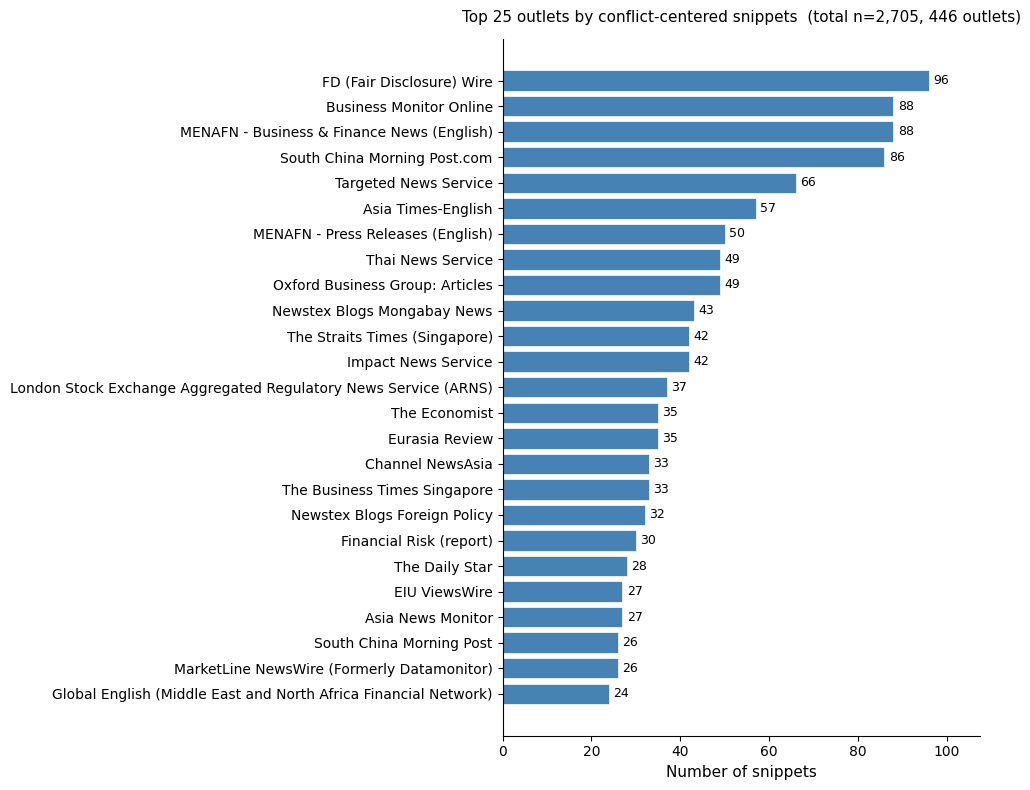

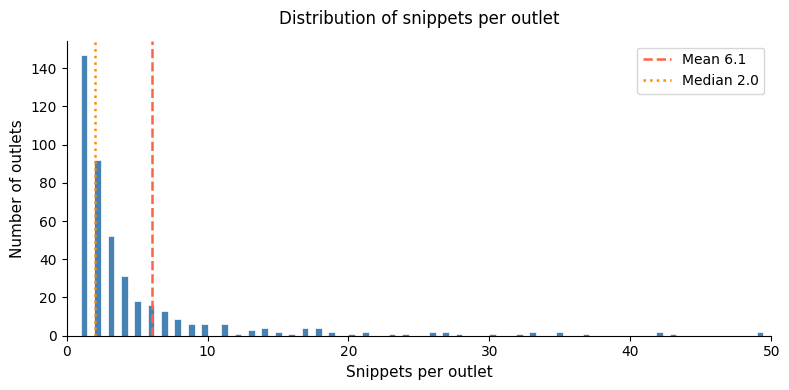

Figures saved.


In [16]:
# ── Snippets per outlet ───────────────────────────────────────────────────────
conflict_snippets_df_filtered['outlet_clean'] = (
    conflict_snippets_df_filtered['outlet']
    .str.split(',').str[0]
    .str.strip()
)

counts = (
    conflict_snippets_df_filtered.groupby('outlet_clean')
    .size()
    .sort_values(ascending=False)
    .reset_index(name='n_snippets')
)

print(f'Total snippets  : {len(conflict_snippets_df_filtered):,}')
print(f'Distinct outlets: {len(counts):,}')
print(f'Mean snippets per outlet: {counts["n_snippets"].mean():.1f}')
print(f'Median          : {counts["n_snippets"].median():.1f}')
print()
print(counts.to_string(index=False))

# ── Figure 1: top 25 outlets ──────────────────────────────────────────────────
top25 = counts.head(25)

fig, ax = plt.subplots(figsize=(10, 8))
bars = ax.barh(top25['outlet_clean'][::-1], top25['n_snippets'][::-1],
               color='steelblue', edgecolor='white', linewidth=0.5)

for bar, val in zip(bars, top25['n_snippets'][::-1]):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height() / 2,
            str(val), va='center', ha='left', fontsize=9)

ax.set_xlabel('Number of snippets', fontsize=11)
ax.set_title(f'Top 25 outlets by conflict-centered snippets  (total n={len(conflict_snippets_df_filtered):,}, {len(counts)} outlets)',
             fontsize=11, pad=12)
ax.spines[['top', 'right']].set_visible(False)
ax.set_xlim(0, top25['n_snippets'].max() * 1.12)
plt.tight_layout()
plt.savefig('../ln_training/conflict_snippets_top25_outlets.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Figure 2: distribution of snippets per outlet ─────────────────────────────
mean_val   = counts['n_snippets'].mean()
median_val = counts['n_snippets'].median()

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(counts['n_snippets'], bins=200, color='steelblue', edgecolor='white', linewidth=0.5)
ax.axvline(mean_val,   color='tomato',     linewidth=1.8, linestyle='--', label=f'Mean {mean_val:.1f}')
ax.axvline(median_val, color='darkorange', linewidth=1.8, linestyle=':',  label=f'Median {median_val:.1f}')
ax.set_xlabel('Snippets per outlet', fontsize=11)
ax.set_ylabel('Number of outlets', fontsize=11)
ax.set_title('Distribution of snippets per outlet', fontsize=12, pad=12)
ax.set_xlim(0, 50)
ax.legend(fontsize=10)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('../ln_training/conflict_snippets_per_outlet_dist.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figures saved.')

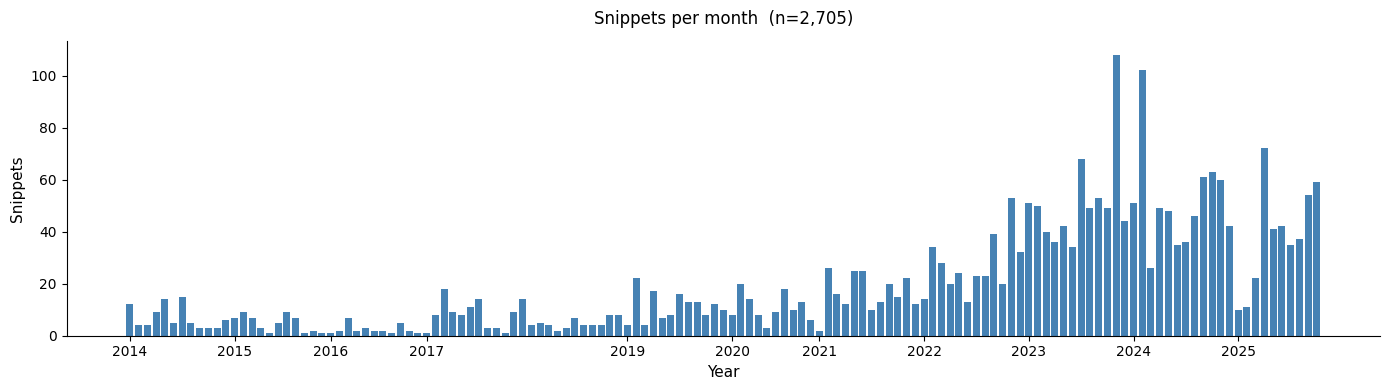

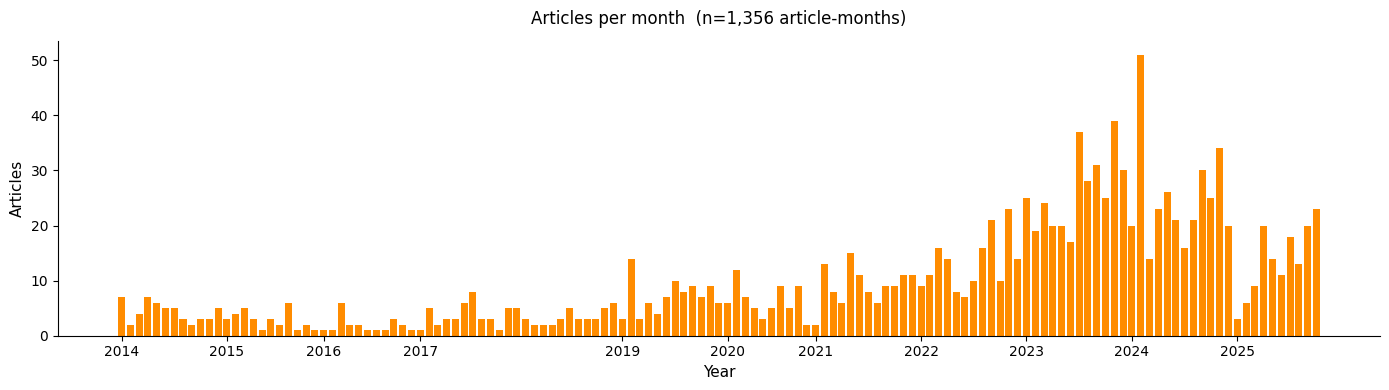

Figures saved.


In [17]:
# ── Distributions over time ───────────────────────────────────────────────────
conflict_snippets_df_filtered['date_parsed'] = pd.to_datetime(conflict_snippets_df_filtered['date'], errors='coerce')
conflict_snippets_df_filtered['year_month']  = conflict_snippets_df_filtered['date_parsed'].dt.to_period('M')

# snippets per month
snippets_by_month = (
    conflict_snippets_df_filtered.groupby('year_month')
    .size()
    .reset_index(name='n_snippets')
    .sort_values('year_month')
)

# articles per month (distinct article_ids)
articles_by_month = (
    conflict_snippets_df_filtered.groupby('year_month')['article_id']
    .nunique()
    .reset_index(name='n_articles')
    .sort_values('year_month')
)

# tick positions at January of each year
def _year_ticks(period_series):
    positions = [i for i, ym in enumerate(period_series) if ym.month == 1]
    labels    = [str(period_series.iloc[i].year) for i in positions]
    return positions, labels

# ── Figure 3: snippets over time ──────────────────────────────────────────────
x = range(len(snippets_by_month))
tick_pos, tick_lbl = _year_ticks(snippets_by_month['year_month'])

fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(list(x), snippets_by_month['n_snippets'], color='steelblue', width=0.8)
ax.set_xticks(tick_pos)
ax.set_xticklabels(tick_lbl, fontsize=10)
ax.set_xlabel('Year', fontsize=11)
ax.set_ylabel('Snippets', fontsize=11)
ax.set_title(f'Snippets per month  (n={len(conflict_snippets_df_filtered):,})', fontsize=12, pad=12)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('../ln_training/conflict_snippets_over_time.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Figure 4: articles over time ──────────────────────────────────────────────
x2 = range(len(articles_by_month))
tick_pos2, tick_lbl2 = _year_ticks(articles_by_month['year_month'])

fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(list(x2), articles_by_month['n_articles'], color='darkorange', width=0.8)
ax.set_xticks(tick_pos2)
ax.set_xticklabels(tick_lbl2, fontsize=10)
ax.set_xlabel('Year', fontsize=11)
ax.set_ylabel('Articles', fontsize=11)
ax.set_title(f'Articles per month  (n={articles_by_month["n_articles"].sum():,} article-months)', fontsize=12, pad=12)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('../ln_training/conflict_articles_over_time.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figures saved.')

In [ ]:
# ── Table: top 50 outlets by snippet count ────────────────────────────────────
top50 = counts.head(50).copy()
top50.insert(0, 'rank', range(1, len(top50) + 1))
top50['share_%'] = (100 * top50['n_snippets'] / counts['n_snippets'].sum()).round(2)

print(f'Top 50 outlets by conflict-centered snippets '
      f'(of {len(counts):,} outlets, {counts["n_snippets"].sum():,} snippets total)')
print(top50.to_string(index=False))

OUT_TOP50 = '../ln_training/conflict_snippets_top50_outlets.xlsx'
top50.to_excel(OUT_TOP50, index=False)
print(f'\nSaved top-50 outlet table to: {OUT_TOP50}')

Top 50 outlets by conflict-centered snippets (of 446 outlets, 2,705 snippets total)
 rank                                                               outlet_clean  n_snippets  share_%
    1                                                  FD (Fair Disclosure) Wire          96     3.55
    2                                                    Business Monitor Online          88     3.25
    3                                 MENAFN - Business & Finance News (English)          88     3.25
    4                                               South China Morning Post.com          86     3.18
    5                                                      Targeted News Service          66     2.44
    6                                                         Asia Times-English          57     2.11
    7                                          MENAFN - Press Releases (English)          50     1.85
    8                                                          Thai News Service          49     1.8